# Solution of Problem Set 3

In [210]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import minimize
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles

np.random.seed(0)

## Exercise 3.1: Ridge Regression

As demonstrated in the lecture on {ref}`sec:regression`, a machine learning model can overfit when its complexity is too high compared with the amount or structure of the data. Methods that reduce this tendency are called **regularisation**. In regression, one common example is **ridge regression** (or L2-regularisation) which extends the ordinary least squares loss function {ref}`eq:lsq-loss` by an additional penalty term:

:::{math}
:enumerated: true
:label: eq:ridge-loss
L(\beta) = \frac{1}{N} \sum_{i=1}^N (y_i - \hat{y}_i)^2 + \lambda \|\beta\|_2^2
:::

The second term penalises large weights, so the model cannot fit the data at any cost; it has to "pay" for every large coefficient. The regularisation parameter $\lambda$ controls the trade-off between fitting the data and keeping the weights small.

**(a) Implement the ridge regression loss for polynomial regression in one dimension.**<br>

In [211]:
def ridge_loss(beta, x, y, lam):
# SOLUTION-START
    predictions = np.polyval(beta, x)
    residuals = predictions - y
    l2_penalty = np.sum(beta[:-1] ** 2)
    loss = np.mean(residuals**2) + lam * l2_penalty
# SOLUTION-END
    return loss

In [212]:
# Ridge regression with numerical optimisation (overfitted polynomial setting)
df = pd.read_csv("../assets/data/data_driven_modelling/methylene_blue.csv")
x = df["Concentration (µM)"].to_numpy(dtype=float)
y = df["Absorbance"].to_numpy(dtype=float)

# standardise the data
x = (x - x.mean()) / x.std()

# Split the data into training and test sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=None)

**(b) Fit the non-regularised and the regularised polynomial models on the methylene blue data from the {ref}`sec:regression` section.**<br>
*Hint: To use the code below, the training data must be stored in `x_train` and `y_train`. Make sure to standardise the features before fitting the models.*

In [213]:
deg = 15
lam = 0.01

# Fit the non-regularised model
beta_non_rigde = np.polyfit(x_train, y_train, deg)

# Fit the regularised model
result = minimize(
    ridge_loss,
    beta_non_rigde,
    args=(x_train, y_train, lam),
    method="BFGS",
    options={"maxiter": 1000}
)

if not result.success:
    print(f"Warning: optimizer did not converge ({result.message}).")

beta_ridge = result.x

**(c) Compute the mean squared error of the non-regularised and the regularised models on the training and test data, respectively. How can you detect overfitting from these values?**<br>
*Hint: Use `np.mean` in combination with `np.polyval` to compute the mean squared error.*

In [214]:
train_loss_ridge = np.mean((y_train - np.polyval(beta_ridge, x_train)) ** 2)
test_loss_ridge = np.mean((y_test - np.polyval(beta_ridge, x_test)) ** 2)

train_loss_non_ridge = np.mean((y_train - np.polyval(beta_non_rigde, x_train)) ** 2)
test_loss_non_ridge = np.mean((y_test - np.polyval(beta_non_rigde, x_test)) ** 2)

print(f"Train MSE (ridge): {train_loss_ridge:.6g}")
print(f"Test MSE (ridge): {test_loss_ridge:.6g}")
print(f"Train MSE (non-ridge): {train_loss_non_ridge:.6g}")
print(f"Test MSE (non-ridge): {test_loss_non_ridge:.6g}")

Train MSE (ridge): 0.000206898
Test MSE (ridge): 8.68506
Train MSE (non-ridge): 6.99044e-26
Test MSE (non-ridge): 6327.63


**(d) Plot the training and test data, as well as the non-regularised and the regularised polynomials.**<br>

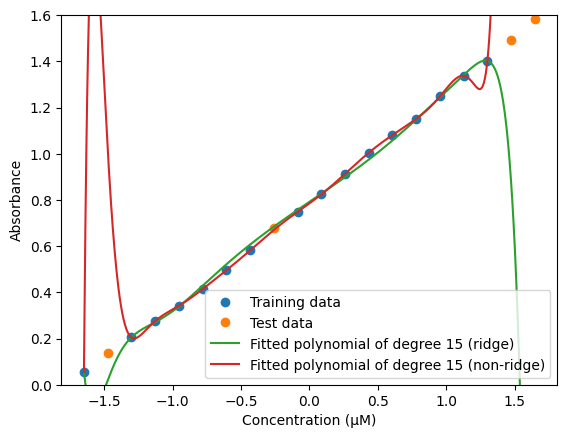

In [215]:
x_range = np.linspace(x.min(), x.max(), 1000)
plt.plot(x_train, y_train, 'o', label='Training data')
plt.plot(x_test, y_test, 'o', label='Test data')
plt.plot(x_range, np.polyval(beta_ridge, x_range), label=f'Fitted polynomial of degree {deg} (ridge)')
plt.plot(x_range, np.polyval(beta_non_rigde, x_range), label=f'Fitted polynomial of degree {deg} (non-ridge)')
plt.xlabel('Concentration (µM)')
plt.ylabel('Absorbance')
plt.ylim(0.0, 1.6)
plt.legend()
plt.show()

:::{note} Multicollinearity in linear regression

The example above, where polynomial regression is applied to a perfectly linear one-dimensional dataset, is intentionally contrived. However, it provides a simple setting for illustrating overfitting and regularisation. In real-world applications, ridge regression is often used for high-dimensional linear regression, especially when features are strongly correlated (multicollinearity). This is an important consideration when engineering features for machine learning models.

:::

## Exercise 3.2: Kernel SVM 

Kernel SVMs address classification problems where the data is not linearly separable in the original feature space. The key idea is to map the data to a higher-dimensional space in which a linear separation becomes possible. To illustrate this idea, we use the artificial dataset shown below, generated with the [`make_circles`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_circles.html) function from the [`scikit-learn`](https://scikit-learn.org/stable/) library.

In [216]:
# Reuse the simple linear SVM from the classification chapter.
# The bias is the feature x_0 = 1, so beta has length dim + 1 and labels are -1/+1.
class SupportVectorMachine:
    def __init__(self, dim=2, alpha=0.1, n_epochs=100, lam=0.1):
        self.alpha = alpha
        self.n_epochs = n_epochs
        self.lam = lam
        self.beta = np.random.randn(dim + 1)

    def net_input(self, x):
        return x @ self.beta

    def fit(self, X, y):
        N = len(X)
        for _ in range(self.n_epochs):
            for xi, yi in zip(X, y):
                update = yi if yi * self.net_input(xi) < 1.0 else 0.0
                self.beta += self.alpha * (update * xi / N - self.lam * self.beta)
        return self

    def predict(self, x):
        return np.where(self.net_input(x) >= 0.0, 1, -1)

(200, 2)


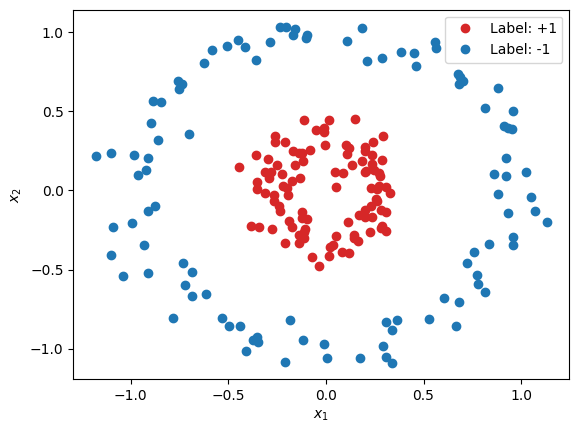

In [217]:
from sklearn.datasets import make_circles

# Two concentric circles in 2D: not linearly separable in the original space.
X, y = make_circles(n_samples=200, factor=0.3, noise=0.08, random_state=0)
print(X.shape)

# inner circle -> +1, outer ring -> -1
y = np.where(y == 1, 1, -1)

plt.plot(X[y == 1, 0], X[y == 1, 1], 'o', color='tab:red', label='Label: +1')
plt.plot(X[y == -1, 0], X[y == -1, 1], 'o', color='tab:blue', label='Label: -1')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.legend()
plt.show()

For this 2D dataset, the mapping can be defined through a non-linear feature map $\phi$:

$$
(x_1, x_2) \rightarrow (x_1, x_2, \phi(x_1, x_2))
$$

**(a) Construct a suitable feature map $\phi$ that allows to separate the two classes in the transformed three-dimensional space. Then, fit a SVM to the transformed data and compute the accuracy on the test set.**<br>

In [218]:
# Radial feature map lifting the data to 3D: (x1, x2) -> (x1, x2, x1^2 + x2^2).
# The squared radius separates the inner from the outer circle along the new axis.
x_3 = X[:, 0] ** 2 + X[:, 1] ** 2
X = np.column_stack([X[:, 0], X[:, 1], x_3])

# Augment with the bias feature x_0 = 1 
X = np.hstack([np.ones((len(X), 1)), X])

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=None)

# Train the SVM in 3D.
svm = SupportVectorMachine(dim=3, alpha=0.5, n_epochs=100, lam=0.001)
svm.fit(X_train, y_train)
print(f"Test accuracy: {np.mean(svm.predict(X_test) == y_test):.2f}")

Test accuracy: 1.00


**(b) Plot the data and the fitted hyperplane in three dimensions.**<br>
*Hint: You can find some examples of how to plot points and surfaces in three dimensions [here](https://matplotlib.org/stable/gallery/mplot3d/index.html).*

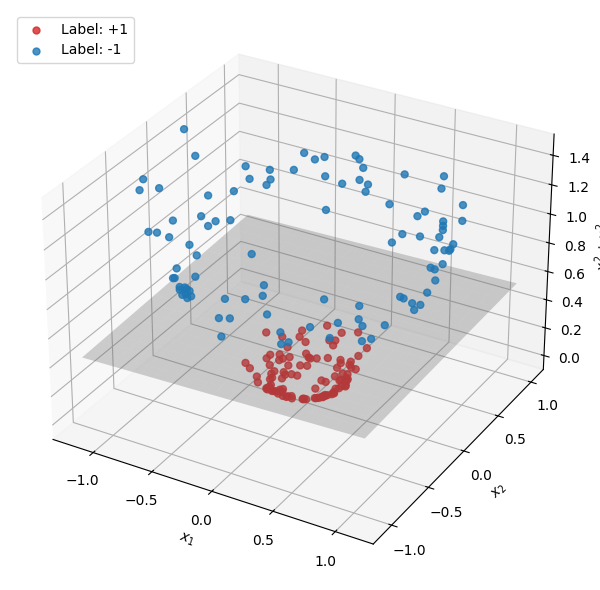

In [219]:
# The learned hyperplane b0 + b1*z1 + b2*z2 + b3*z3 = 0 is a separating plane in 3D.
b0, b1, b2, b3 = svm.beta
g1, g2 = np.meshgrid(
    np.linspace(X[:, 1].min(), X[:, 1].max(), 20),
    np.linspace(X[:, 2].min(), X[:, 2].max(), 20),
)
plane_z = -(b0 + b1 * g1 + b2 * g2) / b3

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(projection="3d")
ax.scatter(X[y == 1, 1], X[y == 1, 2], X[y == 1, 3], color="tab:red", s=25, alpha=0.8, label="Label: +1")
ax.scatter(X[y == -1, 1], X[y == -1, 2], X[y == -1, 3], color="tab:blue", s=25, alpha=0.8, label="Label: -1")
ax.plot_surface(g1, g2, plane_z, color="gray", alpha=0.3, edgecolor="none")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_zlabel("$x_1^2 + x_2^2$")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## Exercise 3.2: $k$-Means Clustering

Revisit the section on {ref}`sec:clustering`. In analogy to a loss function, the $k$-means clustering algorithm minimises the so-called **cluster energy**:

$$
E = \sum_{k=1}^K \sum_{\vec{x}_i \in C_k} \|x_i - m_k\|^2_2
$$

However, the number of clusters $K$ is a parameter of the algorithm and must be specified beforehand.

**(a) For which value of $K$ does the cluster energy $E$ reach its minimum? Why is this not a useful solution, and how is it related to overfitting?**<br>